# Anhedonic AI — Combined Analysis
## Experiment 1: Reward-seeking behaviour | Experiment 2: Knowledge integrity

**Model A:** Qwen2-VL-7B, layers 18–27 ablated | ~1,363 neurons | 0.257% of network

---
- **Exp 1** — Does ablation shift reward choice distribution? (54 MMLU subjects, K=5 folds)
- **Exp 2** — Does ablation damage knowledge? (15 subjects × 3 difficulty tiers, K=5 folds)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
})

BL   = '#2563EB'   # baseline blue
MA   = '#DC2626'   # model A red
CH   = '#9CA3AF'   # chance gray
GR   = '#16A34A'   # green (anhedonic)
OR   = '#EA580C'   # orange (accent)
C10  = '#1D4ED8'
C20  = '#93C5FD'
C30  = '#FCA5A5'
C40  = '#DC2626'

REWARD_LEVELS = [10, 20, 30, 40]
CHANCE_MEAN   = 25.0
CHANCE_RS     = 0.25

# ── Paths ──────────────────────────────────────────────────────────────────
EXP1_RESULTS  = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/results'
EXP2_RESULTS  = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/knowledge_results'

# ── Load Experiment 1 ──────────────────────────────────────────────────────
e1_summary = pd.read_csv(f'{EXP1_RESULTS}/combined_summary.csv')
e1_b = e1_summary[e1_summary['tier']=='baseline']
e1_a = e1_summary[e1_summary['tier']=='model_A']

# Load raw responses for Exp1 reward distribution
import os
from glob import glob

def get_chosen_reward(row):
    try:
        c = int(float(row['Chosen_Option']))
        if 1 <= c <= 4:
            return int(row[f'pts_pos{c}'])
    except: pass
    return np.nan

raw_parts = []
for p in glob(f'{EXP1_RESULTS}/*/detailed_results.csv'):
    raw_parts.append(pd.read_csv(p))
e1_raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
if not e1_raw.empty:
    e1_raw = e1_raw[e1_raw['Is_Multi_Answer'] == False].copy()
    e1_raw['chosen_reward'] = e1_raw.apply(get_chosen_reward, axis=1)
    e1_raw['tier'] = e1_raw['tier'].str.strip()

# ── Load Experiment 2 ──────────────────────────────────────────────────────
e2_summary = pd.read_csv(f'{EXP2_RESULTS}/combined_summary.csv')
e2_b = e2_summary[e2_summary['tier']=='baseline']
e2_a = e2_summary[e2_summary['tier']=='model_A']

e2_sub_parts = []
for p in glob(f'{EXP2_RESULTS}/*/subset_stats.csv'):
    e2_sub_parts.append(pd.read_csv(p))
e2_subsets = pd.concat(e2_sub_parts, ignore_index=True) if e2_sub_parts else pd.DataFrame()

print(f'Exp1 subjects: {e1_summary["subject"].nunique()}  (reward-seeking eval)')
print(f'Exp2 subjects: {e2_summary["subject"].nunique()}  (knowledge eval)')
print(f'\nExp1 — reward-seeking:  baseline={e1_b["mean_pts_mean"].mean():.2f}pts  model_A={e1_a["mean_pts_mean"].mean():.2f}pts  Δ={e1_a["mean_pts_mean"].mean()-e1_b["mean_pts_mean"].mean():+.2f}')
print(f'Exp2 — accuracy:        baseline={e2_b["acc_%_mean"].mean():.2f}%  model_A={e2_a["acc_%_mean"].mean():.2f}%  Δ={e2_a["acc_%_mean"].mean()-e2_b["acc_%_mean"].mean():+.2f}pp')

Exp1 subjects: 57  (reward-seeking eval)
Exp2 subjects: 30  (knowledge eval)

Exp1 — reward-seeking:  baseline=29.20pts  model_A=27.10pts  Δ=-2.10
Exp2 — accuracy:        baseline=66.84%  model_A=63.33%  Δ=-3.51pp


---
# EXPERIMENT 1 — Reward-Seeking Behaviour

## E1.1 — Overall reward choice distribution

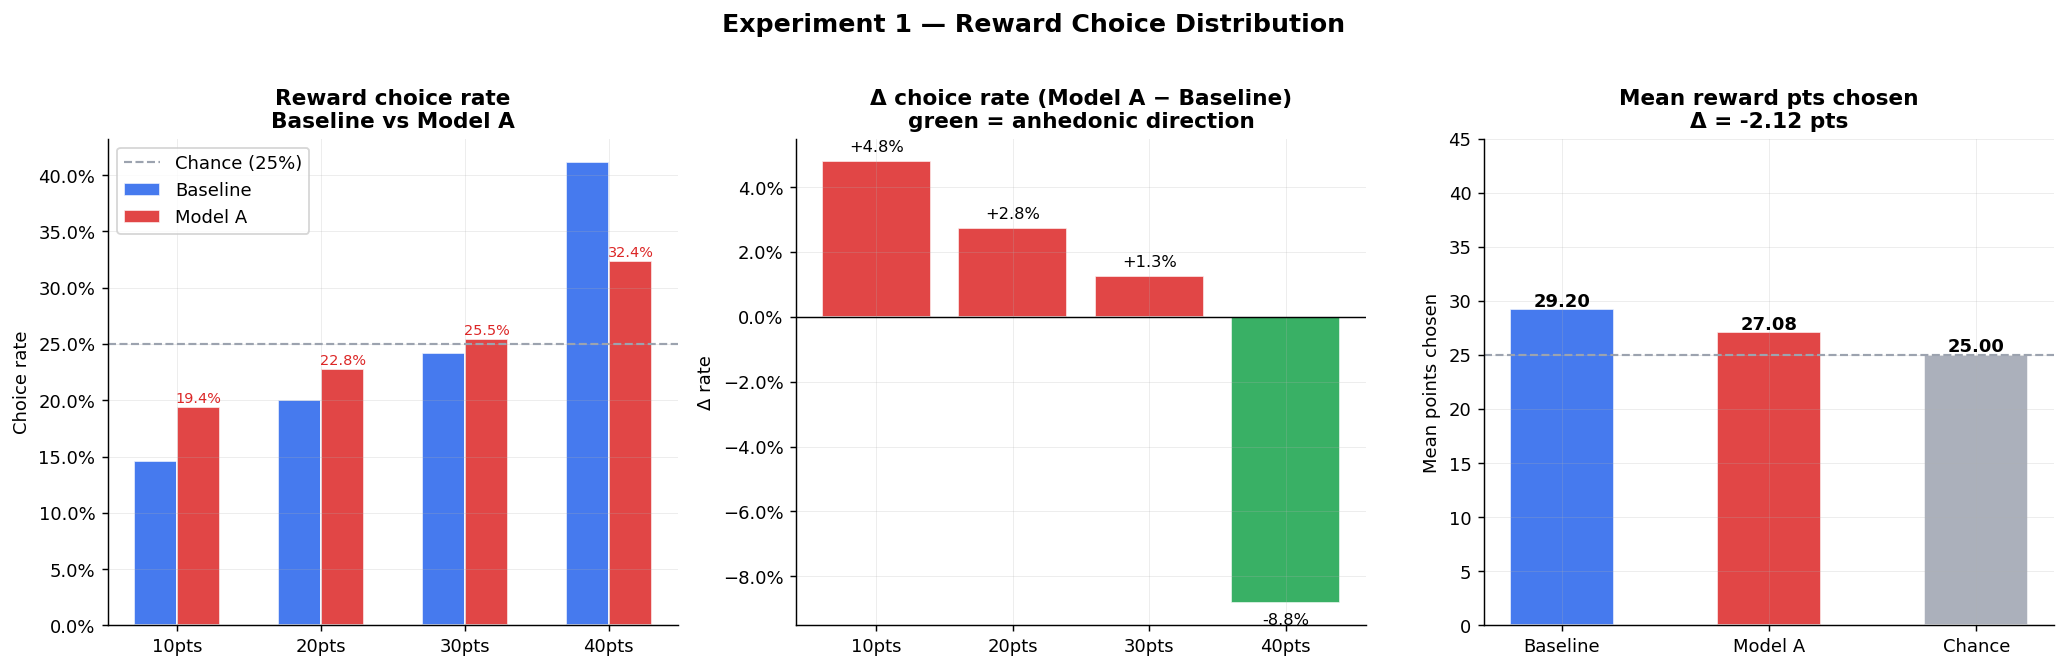

Choice rates:
  10pts  Baseline:0.146  Model A:0.194  Δ:+0.048
  20pts  Baseline:0.200  Model A:0.228  Δ:+0.028
  30pts  Baseline:0.242  Model A:0.255  Δ:+0.013
  40pts  Baseline:0.412  Model A:0.324  Δ:-0.088

Mean pts  Baseline:29.20  Model A:27.08  Chance:25.0


In [2]:
if e1_raw.empty:
    print('No raw Exp1 data found'); 
else:
    valid_b = e1_raw[(e1_raw['tier']=='baseline') & e1_raw['chosen_reward'].notna()]['chosen_reward']
    valid_a = e1_raw[(e1_raw['tier']=='model_A')  & e1_raw['chosen_reward'].notna()]['chosen_reward']

    dist_b = {r: (valid_b==r).mean() for r in REWARD_LEVELS}
    dist_a = {r: (valid_a==r).mean() for r in REWARD_LEVELS}
    delta  = {r: dist_a[r] - dist_b[r] for r in REWARD_LEVELS}

    x, w = np.arange(4), 0.3
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Left: grouped bars
    ax = axes[0]
    ax.bar(x-w/2, [dist_b[r] for r in REWARD_LEVELS], w, label='Baseline', color=BL, alpha=0.85, edgecolor='white')
    ax.bar(x+w/2, [dist_a[r] for r in REWARD_LEVELS], w, label='Model A',  color=MA, alpha=0.85, edgecolor='white')
    ax.axhline(0.25, color=CH, lw=1.2, ls='--', label='Chance (25%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticks(x); ax.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
    ax.set_title('Reward choice rate\nBaseline vs Model A', fontweight='bold')
    ax.set_ylabel('Choice rate')
    ax.legend()
    for i,r in enumerate(REWARD_LEVELS):
        ax.text(i+w/2, dist_a[r]+0.004, f'{dist_a[r]:.1%}', ha='center', fontsize=8, color=MA)

    # Middle: delta bars
    ax2 = axes[1]
    dcols = [GR if delta[r]<0 else MA for r in REWARD_LEVELS]
    ax2.bar(x, [delta[r] for r in REWARD_LEVELS], color=dcols, alpha=0.85, edgecolor='white')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_xticks(x); ax2.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
    ax2.set_title('Δ choice rate (Model A − Baseline)\ngreen = anhedonic direction', fontweight='bold')
    ax2.set_ylabel('Δ rate')
    for i,r in enumerate(REWARD_LEVELS):
        ax2.text(i, delta[r]+(0.002 if delta[r]>=0 else -0.003),
                 f'{delta[r]:+.1%}', ha='center', va='bottom' if delta[r]>=0 else 'top', fontsize=9)

    # Right: mean pts comparison
    ax3 = axes[2]
    means  = [valid_b.mean(), valid_a.mean(), CHANCE_MEAN]
    labels = ['Baseline', 'Model A', 'Chance']
    cols   = [BL, MA, CH]
    bars   = ax3.bar(labels, means, color=cols, alpha=0.85, edgecolor='white', width=0.5)
    ax3.axhline(CHANCE_MEAN, color=CH, lw=1.2, ls='--')
    ax3.set_ylim(0, 45)
    ax3.set_ylabel('Mean points chosen')
    ax3.set_title(f'Mean reward pts chosen\nΔ = {valid_a.mean()-valid_b.mean():+.2f} pts', fontweight='bold')
    for bar, val in zip(bars, means):
        ax3.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.2f}', ha='center', fontweight='bold')

    plt.suptitle('Experiment 1 — Reward Choice Distribution', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_choice_distribution.png', bbox_inches='tight')
    plt.show()

    print(f'Choice rates:')
    for r in REWARD_LEVELS:
        print(f'  {r:>2}pts  Baseline:{dist_b[r]:.3f}  Model A:{dist_a[r]:.3f}  Δ:{delta[r]:+.3f}')
    print(f'\nMean pts  Baseline:{valid_b.mean():.2f}  Model A:{valid_a.mean():.2f}  Chance:{CHANCE_MEAN:.1f}')

## E1.2 — Per-subject: mean points chosen (sorted)

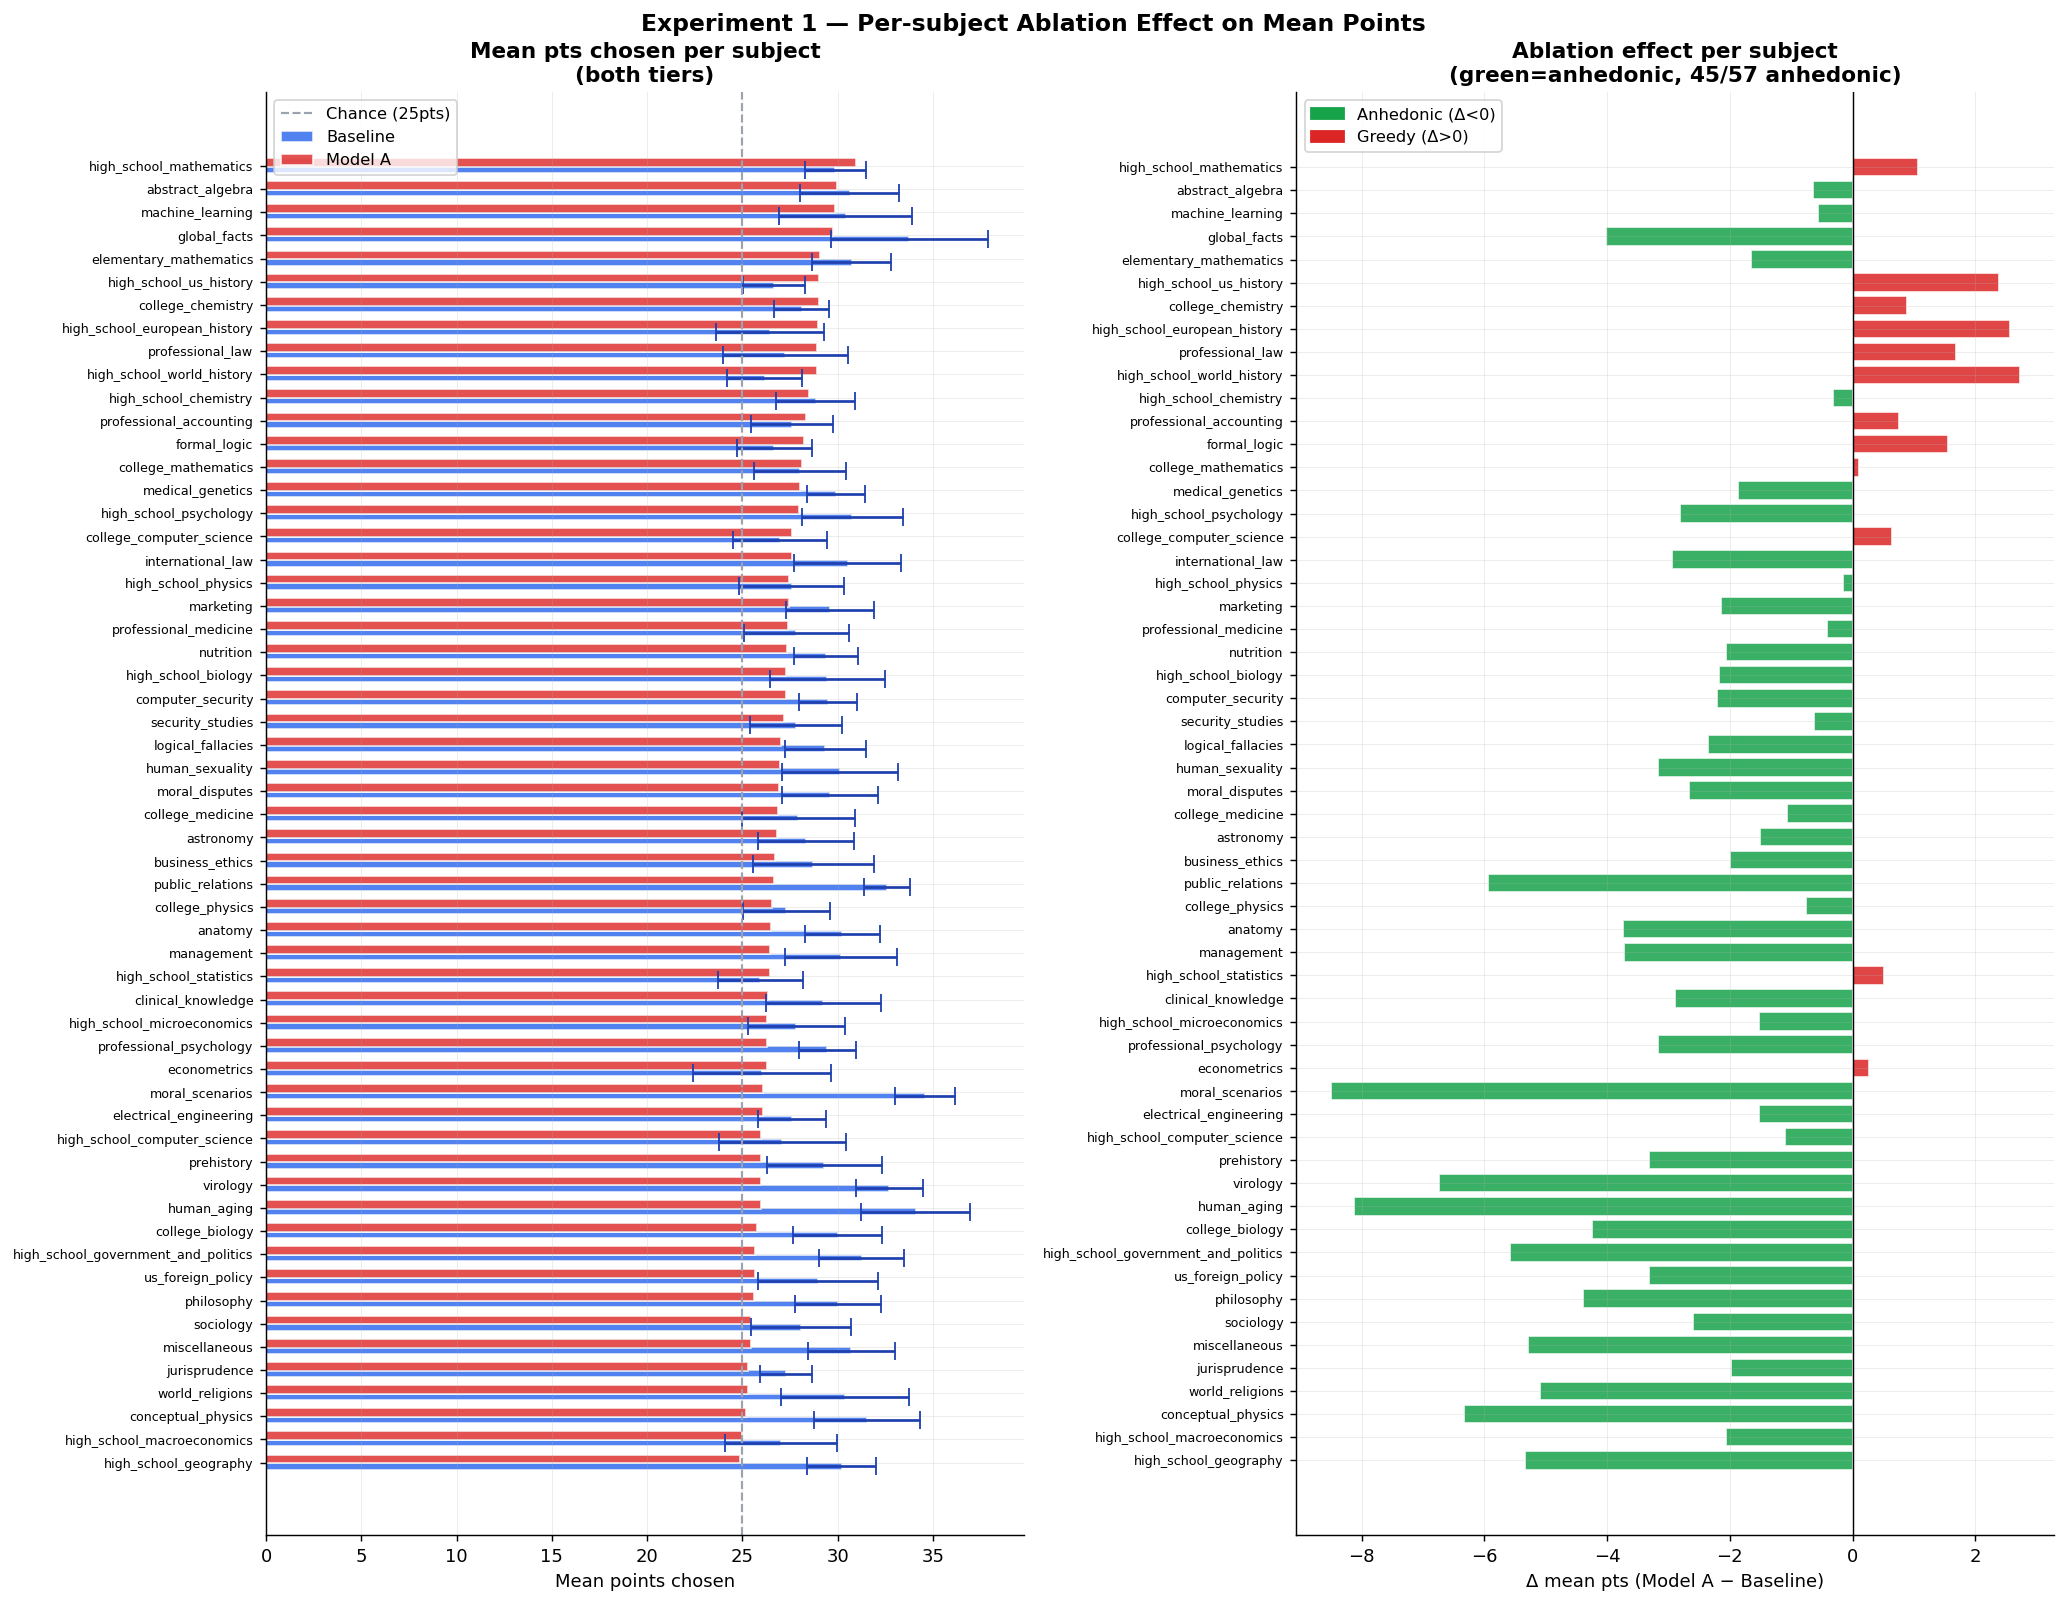

Mean Δ: -2.10 pts  |  Anhedonic: 45/57


In [3]:
# Merge baseline and model_A per subject
pts_b = e1_b.set_index('subject')['mean_pts_mean'].rename('baseline')
pts_a = e1_a.set_index('subject')['mean_pts_mean'].rename('model_A')
std_a = e1_a.set_index('subject')['mean_pts_std'].rename('std_A')
std_b = e1_b.set_index('subject')['mean_pts_std'].rename('std_B')
pts   = pd.concat([pts_b, pts_a, std_b, std_a], axis=1).dropna().sort_values('model_A')
pts['delta'] = pts['model_A'] - pts['baseline']

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(pts)*0.22)))

# Left: absolute mean pts, both tiers
ax = axes[0]
y  = np.arange(len(pts))
ax.barh(y-0.16, pts['baseline'], 0.28, xerr=pts['std_B'], color=BL, alpha=0.8, error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'}, label='Baseline', edgecolor='white')
ax.barh(y+0.16, pts['model_A'],  0.38, color=MA, alpha=0.8, label='Model A',  edgecolor='white')
ax.axvline(CHANCE_MEAN, color=CH, lw=1.2, ls='--', label='Chance (25pts)')
ax.set_yticks(y); ax.set_yticklabels(pts.index, fontsize=7)
ax.set_xlabel('Mean points chosen')
ax.set_title('Mean pts chosen per subject\n(both tiers)', fontweight='bold')
ax.legend(fontsize=9)

# Right: delta (Model A - Baseline)
ax2 = axes[1]
dcols = [GR if d<0 else MA for d in pts['delta']]
ax2.barh(y, pts['delta'], color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(pts.index, fontsize=7)
ax2.set_xlabel('Δ mean pts (Model A − Baseline)')
ax2.set_title(f'Ablation effect per subject\n(green=anhedonic, {(pts["delta"]<0).sum()}/{len(pts)} anhedonic)', fontweight='bold')
patches = [mpatches.Patch(color=GR, label='Anhedonic (Δ<0)'),
           mpatches.Patch(color=MA, label='Greedy (Δ>0)')]
ax2.legend(handles=patches, fontsize=9)

plt.suptitle('Experiment 1 — Per-subject Ablation Effect on Mean Points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_E1_per_subject_delta.png', bbox_inches='tight')
plt.show()
print(f'Mean Δ: {pts["delta"].mean():+.2f} pts  |  Anhedonic: {(pts["delta"]<0).sum()}/{len(pts)}')

## E1.3 — Stacked choice distribution per subject

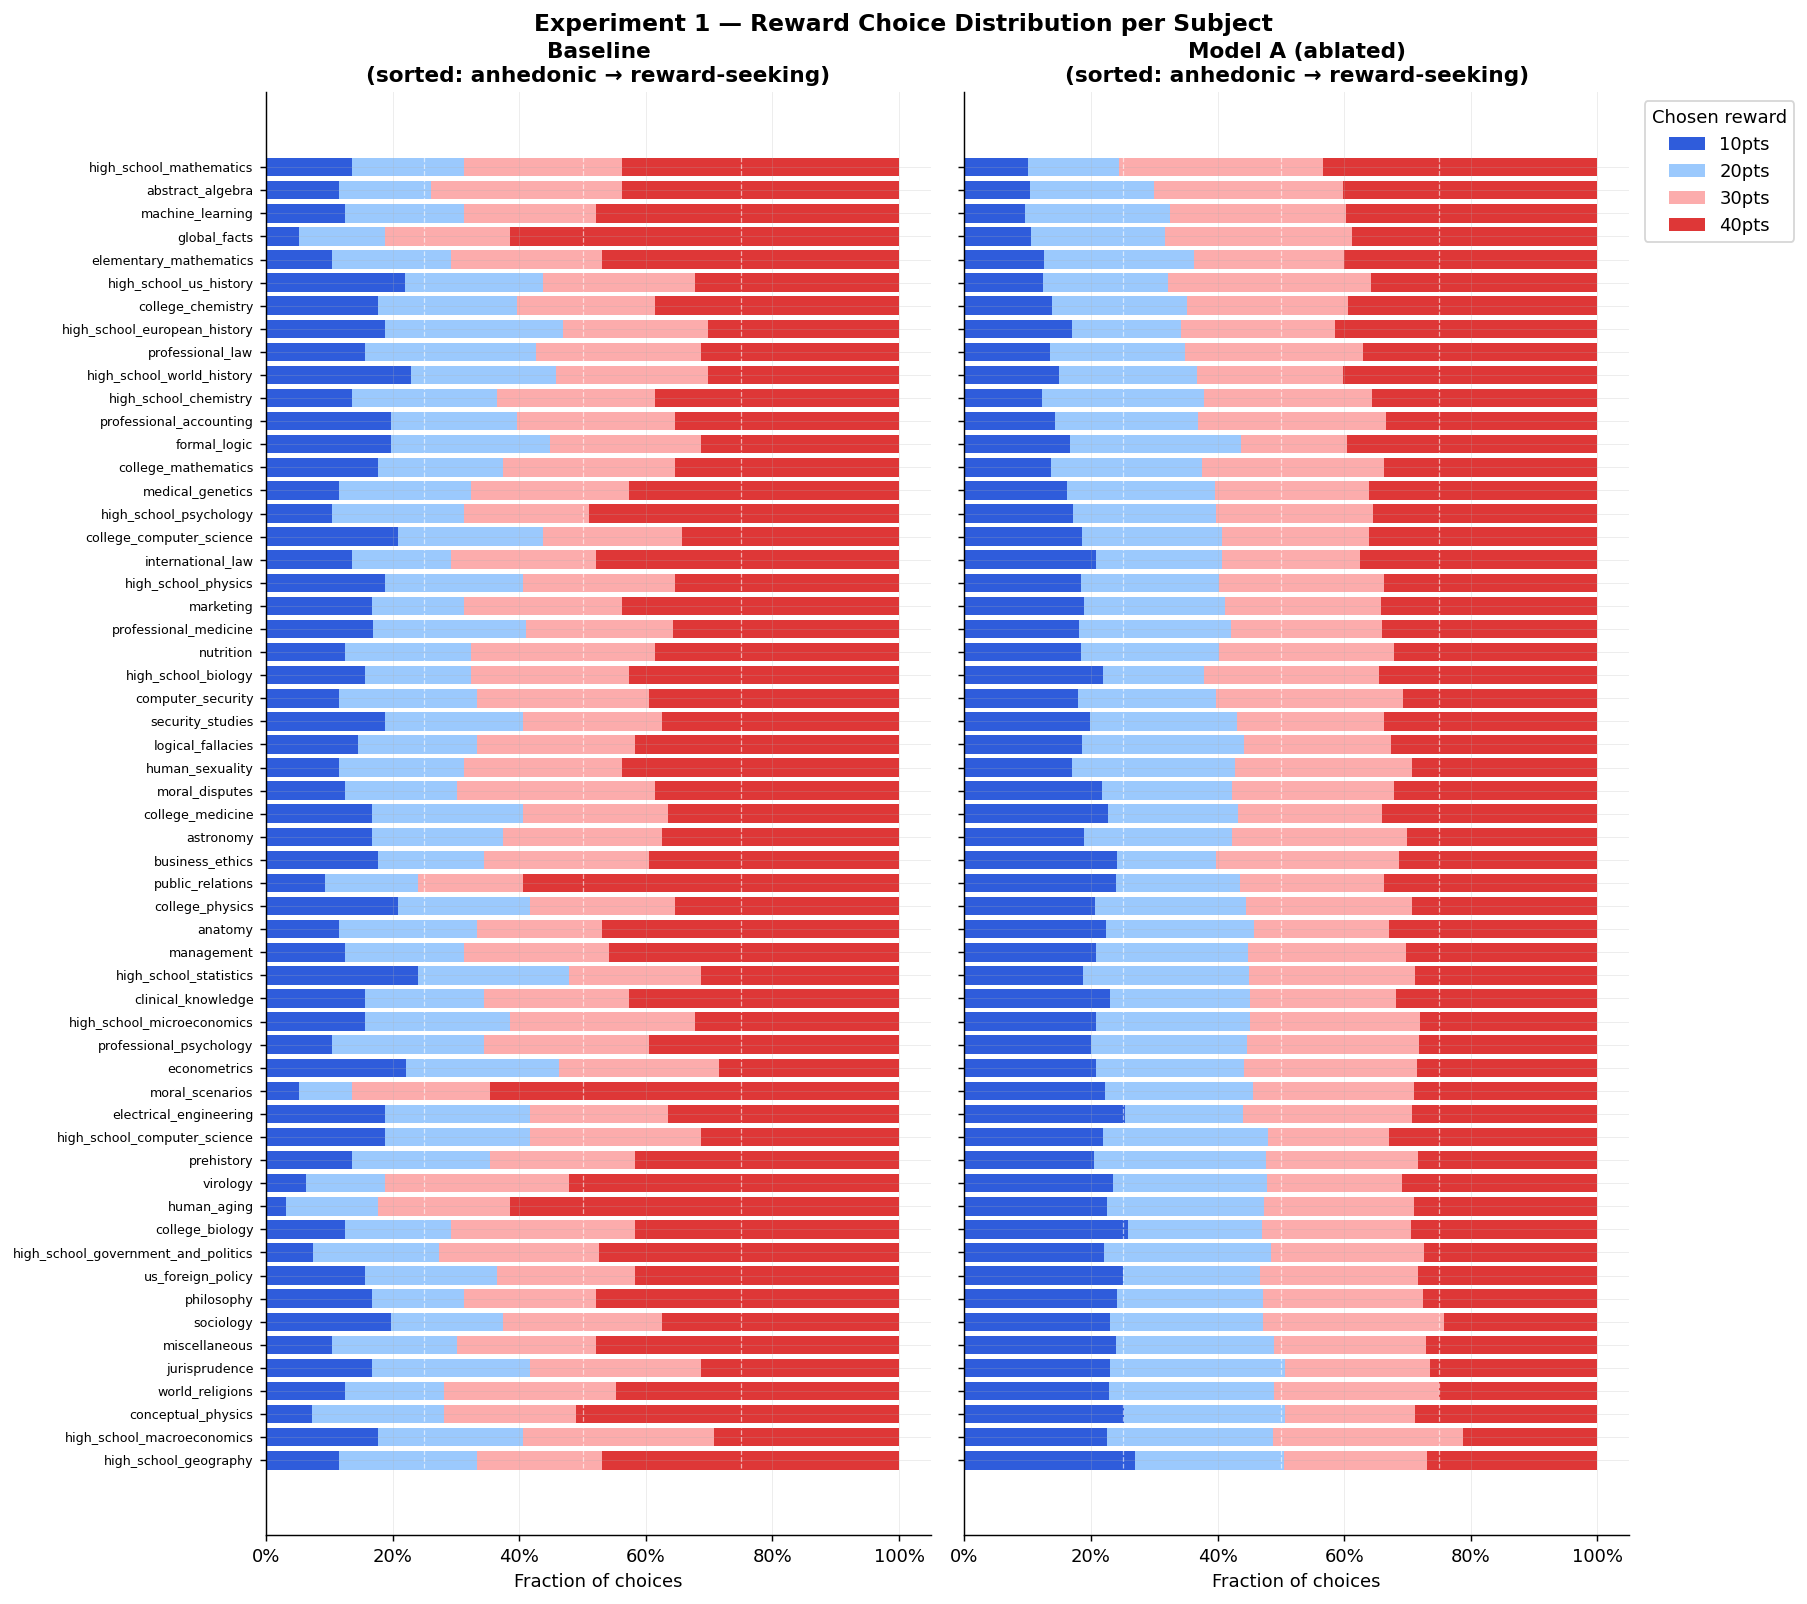

In [4]:
if not e1_raw.empty:
    fracs_b, fracs_a = {}, {}
    for subj, grp in e1_raw[e1_raw['tier']=='baseline'].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs_b[subj] = {r: (v==r).mean() for r in REWARD_LEVELS}
    for subj, grp in e1_raw[e1_raw['tier']=='model_A'].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs_a[subj] = {r: (v==r).mean() for r in REWARD_LEVELS}

    subj_order = pts.index.tolist()  # sorted by Model A mean pts
    fb = pd.DataFrame(fracs_b).T.reindex(subj_order).fillna(0)
    fa = pd.DataFrame(fracs_a).T.reindex(subj_order).fillna(0)
    cmap = {10: C10, 20: C20, 30: C30, 40: C40}

    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(subj_order)*0.22)),
                             sharey=True)
    for ax, frac_df, title in [
        (axes[0], fb, 'Baseline'),
        (axes[1], fa, 'Model A (ablated)'),
    ]:
        left = np.zeros(len(frac_df))
        for r in REWARD_LEVELS:
            vals = frac_df[r].values
            ax.barh(frac_df.index, vals, left=left,
                    color=cmap[r], label=f'{r}pts', alpha=0.92)
            left += vals
        for v in [0.25, 0.5, 0.75]:
            ax.axvline(v, color='white', lw=0.7, ls='--', alpha=0.6)
        ax.set_xlabel('Fraction of choices')
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title(f'{title}\n(sorted: anhedonic → reward-seeking)',
                     fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)

    axes[1].legend(title='Chosen reward', bbox_to_anchor=(1.01,1), loc='upper left')
    plt.suptitle('Experiment 1 — Reward Choice Distribution per Subject',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_stacked_per_subject.png', bbox_inches='tight')
    plt.show()

## E1.4 — 40pt choice rate: K=5 fold error bars

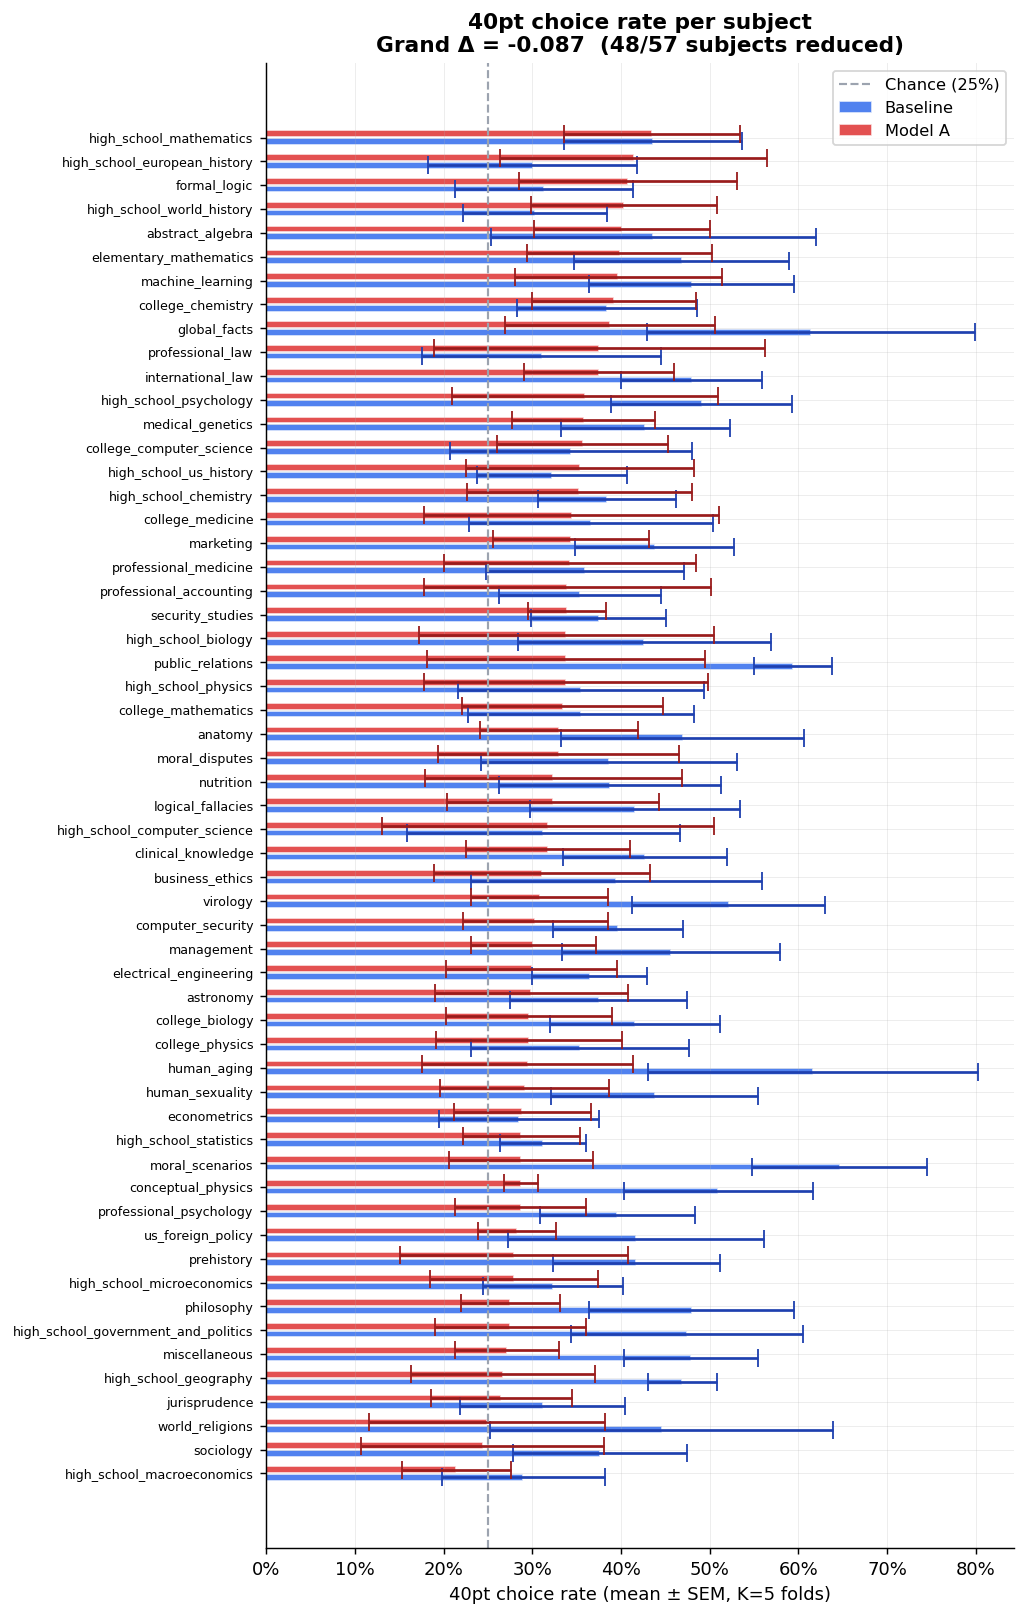

In [5]:
r40_b = e1_b.set_index('subject')[['rate_40pt_mean','rate_40pt_std']].rename(
    columns={'rate_40pt_mean':'mean','rate_40pt_std':'sem'})
r40_a = e1_a.set_index('subject')[['rate_40pt_mean','rate_40pt_std']].rename(
    columns={'rate_40pt_mean':'mean','rate_40pt_std':'sem'})

subj_order_40 = r40_a.sort_values('mean').index.tolist()
y = np.arange(len(subj_order_40))

fig, ax = plt.subplots(figsize=(8, max(6, len(subj_order_40)*0.22)))
ax.barh(y-0.16, r40_b.loc[subj_order_40,'mean'], 0.28,
        xerr=r40_b.loc[subj_order_40,'sem'], color=BL, alpha=0.8,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth': 1.5,'capsize': 5,'ecolor':'#1e40af'})
ax.barh(y+0.16, r40_a.loc[subj_order_40,'mean'], 0.28,
        xerr=r40_a.loc[subj_order_40,'sem'], color=MA, alpha=0.8,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth': 1.5,'capsize': 5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks(y); ax.set_yticklabels(subj_order_40, fontsize=7)
ax.set_xlabel('40pt choice rate (mean ± SEM, K=5 folds)')
delta_40 = r40_a['mean'].mean() - r40_b['mean'].mean()
ax.set_title(f'40pt choice rate per subject\n'
             f'Grand Δ = {delta_40:+.3f}  '
             f'({(r40_a["mean"] < r40_b["mean"]).sum()}/{len(r40_a)} subjects reduced)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_E1_40pt_rate.png', bbox_inches='tight')
plt.show()

## E1.5 — Significance: t-test vs chance per subject

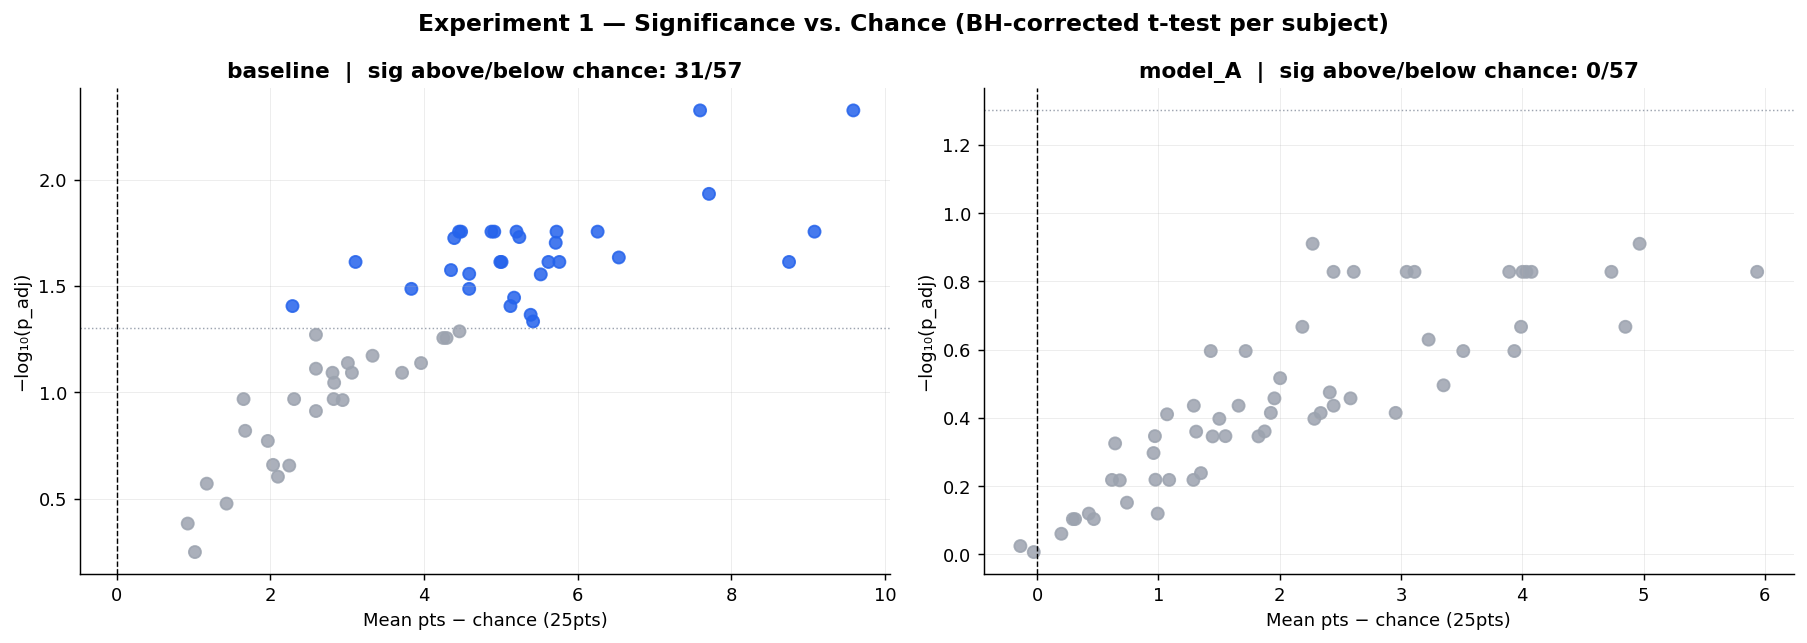

In [6]:
from statsmodels.stats.multitest import multipletests

# Load subset-level scores for t-tests
sub_parts = []
for p in glob(f'{EXP1_RESULTS}/*/subset_stats.csv'):
    sub_parts.append(pd.read_csv(p))
e1_subsets = pd.concat(sub_parts, ignore_index=True) if sub_parts else pd.DataFrame()

if not e1_subsets.empty:
    ttest_rows = []
    for (subj, tier), grp in e1_subsets.groupby(['subject','tier']):
        rr = grp['mean_pts'].values
        if len(rr) >= 2:
            t, p = stats.ttest_1samp(rr, CHANCE_MEAN)
            ttest_rows.append({'subject':subj,'tier':tier,'t':t,'p':p,'mean':rr.mean()})
    ttest = pd.DataFrame(ttest_rows)

    for tier in ['baseline','model_A']:
        td = ttest[ttest['tier']==tier].copy()
        reject, p_adj, _, _ = multipletests(td['p'], method='fdr_bh')
        td['p_adj'] = p_adj; td['sig'] = reject
        ttest.loc[td.index,'p_adj'] = p_adj
        ttest.loc[td.index,'sig']   = reject

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    for ax, tier, color in [(axes[0],'baseline',BL),(axes[1],'model_A',MA)]:
        td = ttest[ttest['tier']==tier]
        pt_colors = [color if s else CH for s in td['sig']]
        ax.scatter(td['mean'] - CHANCE_MEAN, -np.log10(td['p_adj']),
                   c=pt_colors, s=45, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8, ls='--')
        ax.axhline(-np.log10(0.05), color=CH, lw=0.8, ls=':')
        n_sig = td['sig'].sum()
        ax.set_xlabel('Mean pts − chance (25pts)')
        ax.set_ylabel('−log₁₀(p_adj)')
        ax.set_title(f'{tier}  |  sig above/below chance: {n_sig}/{len(td)}',
                     fontweight='bold')

    plt.suptitle('Experiment 1 — Significance vs. Chance (BH-corrected t-test per subject)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_significance.png', bbox_inches='tight')
    plt.show()

---
# EXPERIMENT 2 — Knowledge Integrity

## E2.1 — Overall accuracy: baseline vs Model A with K=5 fold error bars

In [ ]:
acc_b = e2_b.set_index('subject')[['acc_%_mean','acc_%_std','acc_%_std']]
acc_a = e2_a.set_index('subject')[['acc_%_mean','acc_%_std','acc_%_std']]
common = acc_b.index.intersection(acc_a.index)
acc_b, acc_a = acc_b.loc[common], acc_a.loc[common]

# Sort by baseline accuracy
order = acc_b['acc_%_mean'].sort_values().index.tolist()
y = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(order)*0.38)))

# Left: grouped bars with error bars
ax = axes[0]
ax.barh(y-0.16, acc_b.loc[order,'acc_%_mean'], 0.28,
        xerr=acc_b.loc[order,'acc_%_std'], color=BL, alpha=0.82,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth': 1.5,'capsize': 5,'ecolor':'#1e40af'})
ax.barh(y+0.16, acc_a.loc[order,'acc_%_mean'], 0.28,
        xerr=acc_a.loc[order,'acc_%_std'], color=MA, alpha=0.82,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth': 1.5,'capsize': 5,'ecolor':'#991b1b'})
ax.axvline(25, color=CH, lw=1, ls='--', alpha=0.6, label='Chance (25%)')
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Accuracy % (mean ± SEM, K=5 folds)')
ax.set_title('Knowledge accuracy per subject\n(mean ± SEM)', fontweight='bold')
ax.legend(fontsize=9)

# Right: delta bars
ax2 = axes[1]
delta_acc = acc_a.loc[order,'acc_%_mean'] - acc_b.loc[order,'acc_%_mean']
dcols = [GR if d>=0 else MA for d in delta_acc]
ax2.barh(y, delta_acc, color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(order, fontsize=8)
ax2.set_xlabel('Δ accuracy (Model A − Baseline)')
n_better = (delta_acc > 0).sum()
ax2.set_title(f'Ablation effect on knowledge\n'
              f'Mean Δ = {delta_acc.mean():+.2f}pp  |  MA better: {n_better}/{len(delta_acc)}',
              fontweight='bold')

plt.suptitle('Experiment 2 — Knowledge Accuracy: Baseline vs Model A',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_accuracy_per_subject.png', bbox_inches='tight')
plt.show()
print(f'Grand mean — Baseline: {acc_b["acc_%_mean"].mean():.2f}%  Model A: {acc_a["acc_%_mean"].mean():.2f}%  Δ: {delta_acc.mean():+.2f}pp')

## E2.2 — Accuracy by difficulty tier

In [ ]:
diff_cols = {'hard':'#DC2626','medium':'#F59E0B','easy':'#16A34A'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bars by difficulty
ax = axes[0]
tiers_order = ['hard','medium','easy']
x = np.arange(3); w = 0.3
b_means = [e2_b[e2_b['difficulty_tier']==d]['acc_%_mean'].mean() for d in tiers_order]
a_means = [e2_a[e2_a['difficulty_tier']==d]['acc_%_mean'].mean() for d in tiers_order]
b_sems  = [e2_b[e2_b['difficulty_tier']==d]['acc_%_mean'].std()  for d in tiers_order]
a_sems  = [e2_a[e2_a['difficulty_tier']==d]['acc_%_mean'].std()  for d in tiers_order]

ax.bar(x-w/2, b_means, w, yerr=b_sems, label='Baseline', color=BL, alpha=0.85,
       error_kw={'elinewidth': 1.5,'capsize': 5}, edgecolor='white')
ax.bar(x+w/2, a_means, w, yerr=a_sems, label='Model A',  color=MA, alpha=0.85,
       error_kw={'elinewidth': 1.5,'capsize': 5}, edgecolor='white')
ax.axhline(25, color=CH, lw=1, ls='--', alpha=0.5, label='Chance')
ax.set_xticks(x); ax.set_xticklabels(['Hard', 'Medium', 'Easy'])
ax.set_ylabel('Accuracy %')
ax.set_title('Knowledge accuracy by difficulty tier\n(mean ± SEM across subjects)', fontweight='bold')
ax.legend()

# Right: delta by difficulty — this is the key plot
ax2 = axes[1]
deltas   = [a - b for a, b in zip(a_means, b_means)]
d_colors = [diff_cols[t] for t in tiers_order]
bars = ax2.bar(tiers_order, deltas, color=d_colors, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Δ accuracy (Model A − Baseline)')
ax2.set_title('Ablation effect by difficulty\nDoes ablation hurt more on harder subjects?',
              fontweight='bold')
for bar, d in zip(bars, deltas):
    ax2.text(bar.get_x()+bar.get_width()/2,
             d + (0.3 if d>=0 else -0.5),
             f'{d:+.2f}pp', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Experiment 2 — Difficulty-Stratified Knowledge Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_accuracy_by_difficulty.png', bbox_inches='tight')
plt.show()

print('Δ accuracy by difficulty tier:')
for d, delta in zip(tiers_order, deltas):
    print(f'  {d:<8}: {delta:+.2f}pp')

## E2.3 — Per-question accuracy (Q1–Q4): does position matter?

In [ ]:
q_cols = ['acc_q1_%_mean','acc_q2_%_mean','acc_q3_%_mean','acc_q4_%_mean']
q_sems = ['acc_q1_%_std', 'acc_q2_%_std', 'acc_q3_%_std', 'acc_q4_%_std']

q_b = e2_b[q_cols + q_sems].mean()
q_a = e2_a[q_cols + q_sems].mean()

x = np.arange(4); w = 0.3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.bar(x-w/2, [q_b[c] for c in q_cols], w, label='Baseline',
       yerr=[q_b[s] for s in q_sems], color=BL, alpha=0.85, edgecolor='white',
       error_kw={'elinewidth': 1.5,'capsize': 5})
ax.bar(x+w/2, [q_a[c] for c in q_cols], w, label='Model A',
       yerr=[q_a[s] for s in q_sems], color=MA, alpha=0.85, edgecolor='white',
       error_kw={'elinewidth': 1.5,'capsize': 5})
ax.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.set_ylabel('Accuracy %')
ax.set_title('Accuracy per question position\n(mean ± SEM across subjects)', fontweight='bold')
ax.legend()

ax2 = axes[1]
deltas_q = [q_a[c]-q_b[c] for c in q_cols]
dc = [GR if d>=0 else MA for d in deltas_q]
ax2.bar(['Q1','Q2','Q3','Q4'], deltas_q, color=dc, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Δ accuracy')
ax2.set_title('Δ accuracy per position (Model A − Baseline)\nIs any question slot disproportionately affected?',
              fontweight='bold')
for i, d in enumerate(deltas_q):
    ax2.text(i, d+(0.2 if d>=0 else -0.4), f'{d:+.2f}pp',
             ha='center', fontsize=10)

plt.suptitle('Experiment 2 — Per-Question Position Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_per_question.png', bbox_inches='tight')
plt.show()

## E2.4 — K=5 fold stability: accuracy across subsets

In [ ]:
if not e2_subsets.empty:
    fold_ids = sorted(e2_subsets['subset'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, tier, color, label in [
        (axes[0], 'baseline', BL, 'Baseline'),
        (axes[1], 'model_A',  MA, 'Model A'),
    ]:
        td = e2_subsets[e2_subsets['tier']==tier]
        fold_data = [td[td['subset']==k]['acc_%'].dropna().values for k in fold_ids]
        vp = ax.violinplot(fold_data, positions=fold_ids, showmedians=True)
        for body in vp['bodies']:
            body.set_facecolor(color); body.set_alpha(0.55)
        ax.axhline(25, color=CH, lw=1.2, ls='--', label='Chance')
        grand_mean = td['acc_%'].mean()
        ax.axhline(grand_mean, color=color, lw=1.2, ls='-',
                   label=f'{label} mean ({grand_mean:.1f}%)')
        f, p_anova = stats.f_oneway(*fold_data)
        ax.set_xticks(fold_ids); ax.set_xlabel('Subset (fold)')
        ax.set_ylabel('Accuracy %')
        ax.set_title(f'{label} — fold stability\nANOVA F={f:.2f}, p={p_anova:.3f}',
                     fontweight='bold')
        ax.legend(fontsize=9)

    plt.suptitle('Experiment 2 — K=5 Fold Stability', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP2_RESULTS}/fig_E2_fold_stability.png', bbox_inches='tight')
    plt.show()

---
# COMBINED — Reward-seeking vs Knowledge: the full picture

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Mean pts chosen (Exp1) ───────────────────────────────────────
ax = axes[0]
categories = ['Baseline', 'Model A', 'Chance']
means_pts  = [
    e1_b['mean_pts_mean'].mean(),
    e1_a['mean_pts_mean'].mean(),
    CHANCE_MEAN
]
sems_pts   = [e1_b['mean_pts_std'].mean(), e1_a['mean_pts_std'].mean(), 0]
cols_pts   = [BL, MA, CH]
bars = ax.bar(categories, means_pts, yerr=sems_pts, color=cols_pts,
              alpha=0.85, edgecolor='white', width=0.5,
              error_kw={'elinewidth': 1.5,'capsize': 5})
ax.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax.set_ylim(0, 40)
ax.set_ylabel('Mean points chosen')
ax.set_title('Exp 1: Reward-seeking\nMean pts chosen ± SEM', fontweight='bold')
for bar, val in zip(bars, means_pts):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}',
            ha='center', fontweight='bold', fontsize=11)

# ── Panel 2: 40pt choice rate (Exp1) ─────────────────────────────────────
ax2 = axes[1]
r40_means = [e1_b['rate_40pt_mean'].mean(), e1_a['rate_40pt_mean'].mean(), CHANCE_RS]
r40_sems  = [e1_b['rate_40pt_std'].mean(),  e1_a['rate_40pt_std'].mean(),  0]
bars2 = ax2.bar(categories, r40_means, yerr=r40_sems, color=cols_pts,
                alpha=0.85, edgecolor='white', width=0.5,
                error_kw={'elinewidth': 1.5,'capsize': 5})
ax2.axhline(CHANCE_RS, color=CH, lw=1, ls='--', alpha=0.5)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('40pt choice rate')
delta_40_grand = e1_a['rate_40pt_mean'].mean() - e1_b['rate_40pt_mean'].mean()
ax2.set_title(f'Exp 1: 40pt choice rate\nΔ = {delta_40_grand:+.3f} ({delta_40_grand*100:+.1f}pp)',
              fontweight='bold')
for bar, val in zip(bars2, r40_means):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.004, f'{val:.1%}',
             ha='center', fontweight='bold', fontsize=11)

# ── Panel 3: Knowledge accuracy (Exp2) ────────────────────────────────────
ax3 = axes[2]
acc_means = [e2_b['acc_%_mean'].mean(), e2_a['acc_%_mean'].mean(), 25.0]
acc_sems  = [e2_b['acc_%_std'].mean(),  e2_a['acc_%_std'].mean(),  0]
bars3 = ax3.bar(categories, acc_means, yerr=acc_sems, color=cols_pts,
                alpha=0.85, edgecolor='white', width=0.5,
                error_kw={'elinewidth': 1.5,'capsize': 5})
ax3.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 85)
ax3.set_ylabel('Accuracy %')
delta_acc_grand = e2_a['acc_%_mean'].mean() - e2_b['acc_%_mean'].mean()
ax3.set_title(f'Exp 2: Knowledge accuracy\nΔ = {delta_acc_grand:+.2f}pp  (knowledge largely intact)',
              fontweight='bold')
for bar, val in zip(bars3, acc_means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.6, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Anhedonic AI — Combined Summary\n'
             'Ablation attenuates reward-seeking while largely preserving knowledge',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_COMBINED_summary.png', bbox_inches='tight')
plt.show()

print('=== COMBINED FINAL SUMMARY ===')
print(f'Exp1 — Mean pts chosen    : baseline={e1_b["mean_pts_mean"].mean():.2f}  model_A={e1_a["mean_pts_mean"].mean():.2f}  Δ={e1_a["mean_pts_mean"].mean()-e1_b["mean_pts_mean"].mean():+.2f}')
print(f'Exp1 — 40pt choice rate   : baseline={e1_b["rate_40pt_mean"].mean():.3f}  model_A={e1_a["rate_40pt_mean"].mean():.3f}  Δ={delta_40_grand:+.3f}')
print(f'Exp2 — Knowledge accuracy : baseline={e2_b["acc_%_mean"].mean():.2f}%  model_A={e2_a["acc_%_mean"].mean():.2f}%  Δ={delta_acc_grand:+.2f}pp')
print(f'\nConclusion: ablation primarily attenuates reward-seeking (Δ40pt={delta_40_grand*100:+.1f}pp)')
print(f'with modest knowledge cost (Δacc={delta_acc_grand:+.2f}pp), confirming reward-valuation role of L18-27')